### Imports

In [1]:
import torch

from src.config import CONFIG
from src.run_train import train_and_benchmark
from src.types.dataset_type import DatasetType
from src.types.filterbank_type import FilterbankType
from src.types.model_type import ModelType
from src.utils.hyperparameter_sweep_utils import run_hyperparameter_sweep
from src.utils.plotting_utils import plot_training_history

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
MODEL = ModelType.SNN
DATASET = DatasetType.AUDIOMNIST
FILTERBANK = FilterbankType.MEL

### Device

In [3]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Hyperparameter Tuning

In [4]:
if CONFIG.hyperparameter_tuning.should_run:
    run_hyperparameter_sweep(device, MODEL, DATASET, FILTERBANK)

### Training

Hyperparameters used: {'lr': 0.008155826180252698, 'model_init': {'beta_init': 0.5845752633099218, 'slope': 10}}

Training SNN...
[Epoch 1/5]


Validation: 100%|██████████| 12/12 [00:04<00:00,  2.89batches/s]


Train Loss: 2.59 | Train Accuracy: 10.83% | Val Loss: 2.25 | Val Accuracy: 13.97%
Epoch Duration: 20s | Total Time Elapsed: 20s

[Epoch 2/5]


Validation: 100%|██████████| 12/12 [00:00<00:00, 13.68batches/s]


Train Loss: 2.05 | Train Accuracy: 26.05% | Val Loss: 2.26 | Val Accuracy: 20.70%
Epoch Duration: 13s | Total Time Elapsed: 34s

[Epoch 3/5]


...

Train Loss: 1.02 | Train Accuracy: 63.77% | Val Loss: 2.08 | Val Accuracy: 40.43%
Epoch Duration: 13s | Total Time Elapsed: 60s

[Epoch 5/5]


Validation: 100%|██████████| 12/12 [00:00<00:00, 13.30batches/s]


Train Loss: 0.64 | Train Accuracy: 79.58% | Val Loss: 2.04 | Val Accuracy: 44.50%
Epoch Duration: 14s | Total Time Elapsed: 74s

Training completed in 74s
Best model had an accuracy of 44.50%
Running benchmark on test set...


Testing: 100%|██████████| 12/12 [00:05<00:00,  2.29batches/s]


Test Accuracy: 46.00% | Total MACs: 0 | Total ACs: 297,968
{'model': 'snn', 'dataset': 'audiomnist', 'filterbank': 'mel', 'device': 'mps', 'training_time': 74.2, 'num_epochs': 5, 'hyperparameters': {'lr': 0.008155826180252698, 'model_init': {'beta_init': 0.5845752633099218, 'slope': 10}}, 'best_val_accuracy': 44.5, 'benchmark_accuracy': 46.0, 'macs': 0, 'acs': 297968, 'epoch_history': {'train_losses': [2.5852432404795, 2.0518808800687074, 1.3407082480769004, 1.0170179426029164, 0.6441307798508675], 'train_accs': [10.828293010752688, 26.050067204301076, 52.637768817204304, 63.772681451612904, 79.57829301075269], 'val_losses': [2.2483548323313394, 2.2587549487749734, 2.5521541237831116, 2.0785945852597556, 2.043493608633677], 'val_accs': [13.966666666666667, 20.7, 25.9, 40.43333333333333, 44.5]}}


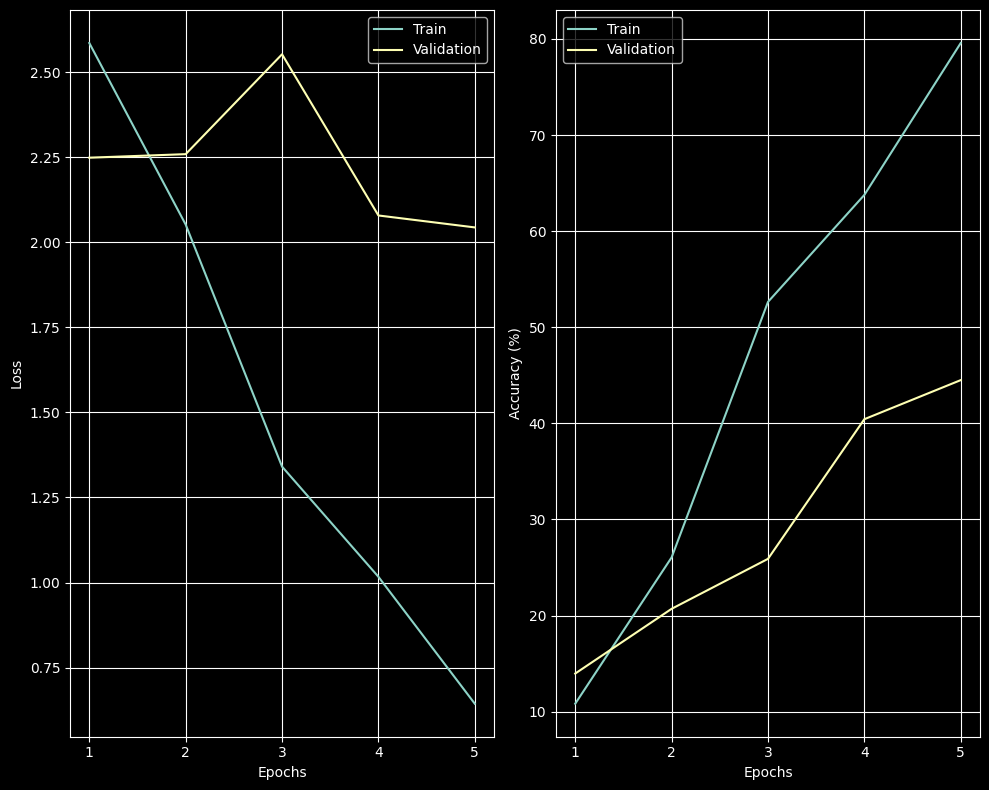

In [5]:
results = train_and_benchmark(device, MODEL, DATASET, FILTERBANK)
plot_training_history(**results['epoch_history'])